In [ ]:
# Import data handling, plotting, and scikit-learn tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report)
import json, os

df = pd.read_csv('../data/raw/rice.csv')
print(df.shape)
df.head()

(3810, 8)


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo


In [2]:

df['Class_encoded'] = df['Class'].astype('category').cat.codes


In [3]:
X = df.drop(columns=['Class', 'Class_encoded'])
y = df['Class_encoded']

# Fixed split shared by ALL member notebooks so results are directly comparable
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (3048, 7)  Test: (762, 7)


In [4]:
#Hyperparameter tuning with GridSearchCV (5-fold)
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5,
                     scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_params = grid.best_params_
print("Best params:", best_params)


Best params: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [5]:
#K-fold cross-validation on the training set

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='accuracy')
print("CV accuracy per fold:", cv_scores.round(4))
print(f"CV mean accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


CV accuracy per fold: [0.9328 0.9393 0.9328 0.9097 0.9278]
CV mean accuracy: 0.9285 (+/- 0.0101)


Test Accuracy  : 0.9199
Test Precision : 0.9067
Test Recall    : 0.9587
Test F1-score  : 0.9320

              precision    recall  f1-score   support

      Cammeo       0.94      0.87      0.90       326
    Osmancik       0.91      0.96      0.93       436

    accuracy                           0.92       762
   macro avg       0.92      0.91      0.92       762
weighted avg       0.92      0.92      0.92       762



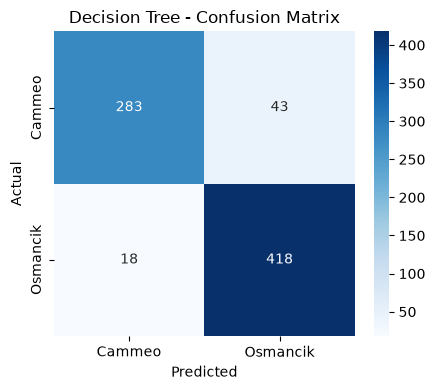

In [6]:
# Evaluate on the held-out test set
pos_val = 1  

y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=pos_val)
rec = recall_score(y_test, y_pred, pos_label=pos_val)
f1 = f1_score(y_test, y_pred, pos_label=pos_val)

print(f"Test Accuracy  : {acc:.4f}")
print(f"Test Precision : {prec:.4f}")
print(f"Test Recall    : {rec:.4f}")
print(f"Test F1-score  : {f1:.4f}\n")

print(classification_report(y_test, y_pred, target_names=['Cammeo', 'Osmancik']))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cammeo', 'Osmancik'], yticklabels=['Cammeo', 'Osmancik'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree - Confusion Matrix')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/decision_tree_confusion_matrix.png', dpi=150)
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3272\2875656629.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


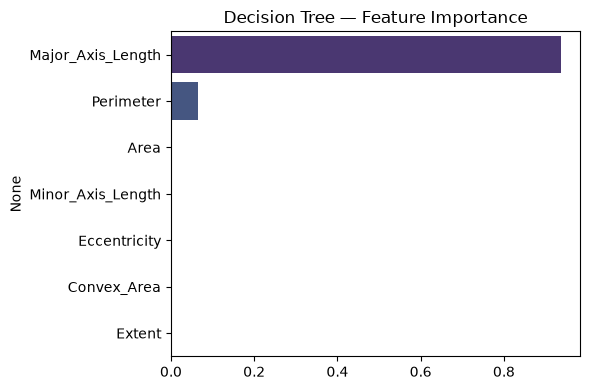

Major_Axis_Length    0.936025
Perimeter            0.063975
Area                 0.000000
Minor_Axis_Length    0.000000
Eccentricity         0.000000
Convex_Area          0.000000
Extent               0.000000
dtype: float64

In [7]:
#Bonus - Feature importance
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Decision Tree — Feature Importance')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/decision_tree_feature_importance.png', dpi=150)
plt.show()
importances


In [8]:
#Save results for the group comparison notebook
os.makedirs('../results/logs', exist_ok=True)
results = {
    'member': 'IT25101432',
    'model': 'Decision Tree',
    'best_params': best_params,
    'cv_mean_accuracy': round(float(cv_scores.mean()), 4),
    'cv_std_accuracy': round(float(cv_scores.std()), 4),
    'test_accuracy': round(float(acc), 4),
    'test_precision': round(float(prec), 4),
    'test_recall': round(float(rec), 4),
    'test_f1': round(float(f1), 4),
}
with open('../results/logs/Member3_Decision_Tree_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))


{
  "member": "IT25101432",
  "model": "Decision Tree",
  "best_params": {
    "criterion": "entropy",
    "max_depth": 3,
    "min_samples_leaf": 1,
    "min_samples_split": 2
  },
  "cv_mean_accuracy": 0.9285,
  "cv_std_accuracy": 0.0101,
  "test_accuracy": 0.9199,
  "test_precision": 0.9067,
  "test_recall": 0.9587,
  "test_f1": 0.932
}
